In [1]:
import os
import numpy as np  
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
from stargazer.stargazer import Stargazer

In [10]:

df_path = os.path.join("..", "data", "combined.csv")   # ../data/combined.csv from src/
assert os.path.exists(df_path), f"File not found: {df_path}"
df = pd.read_csv(df_path)
df.head(15)

,Timestamp,Score,Block,What is your age range?,What is your age range?.1,What is your gender?,How would you rate your Jenga building skills?,Are you in a hurry right now?,Time Taken,Notes
0,2/20/2026 15:23:51,NaN,Treatment 1,23,NaN,Female,3,Yes,35.75,little bit- inch
1,2/20/2026 15:28:53,NaN,Treatment 1,32,NaN,Male,4,No,37.14,NaN
2,2/20/2026 15:32:09,NaN,Treatment 2,29,NaN,Male,1,No,43.75,NaN
3,2/20/2026 15:40:52,NaN,Treatment 2,18,NaN,Female,3,No,54.96,she rejected the reward
4,2/20/2026 15:44:11,NaN,Treatment 1,21,NaN,Male,5,No,39.95,he rejected the reward
5,2/20/2026 15:46:40,NaN,Treatment 2,21,NaN,Female,3,No,29.71,NaN
6,2/20/2026 15:48:32,NaN,Treatment 1,21,NaN,Female,4,No,31.55,she volunteered
7,2/20/2026 15:53:22,NaN,Treatment 1,22,NaN,Male,5,Yes,52.80,NaN
8,2/20/2026 15:55:33,NaN,Treatment 1,19,NaN,Female,2,No,49.40,NaN
9,2/20/2026 15:57:46,NaN,Treatment 2,27,NaN,Male,1,Yes,48.94,NaN


In [11]:
df.drop(columns = ["What is your age range?.1","Notes"],inplace = True)
df

,Timestamp,Score,Block,What is your age range?,What is your gender?,How would you rate your Jenga building skills?,Are you in a hurry right now?,Time Taken
0,2/20/2026 15:23:51,NaN,Treatment 1,23,Female,3,Yes,35.75
1,2/20/2026 15:28:53,NaN,Treatment 1,32,Male,4,No,37.14
2,2/20/2026 15:32:09,NaN,Treatment 2,29,Male,1,No,43.75
3,2/20/2026 15:40:52,NaN,Treatment 2,18,Female,3,No,54.96
4,2/20/2026 15:44:11,NaN,Treatment 1,21,Male,5,No,39.95
5,2/20/2026 15:46:40,NaN,Treatment 2,21,Female,3,No,29.71
6,2/20/2026 15:48:32,NaN,Treatment 1,21,Female,4,No,31.55
7,2/20/2026 15:53:22,NaN,Treatment 1,22,Male,5,Yes,52.80
8,2/20/2026 15:55:33,NaN,Treatment 1,19,Female,2,No,49.40
9,2/20/2026 15:57:46,NaN,Treatment 2,27,Male,1,Yes,48.94


In [19]:
# ...existing code...
# detect likely treatment column and hurry column, then map values
t_col_candidates = ['Block', 'Treatment', 'block', 'group']
tcol = next((c for c in t_col_candidates if c in df.columns), None)
if tcol is None:
    raise KeyError("Treatment column not found. Look for one of: " + ", ".join(t_col_candidates))

# clean and map treatments: "Treatment 1" -> 1, "Treatment 2" -> 2
df[tcol] = df[tcol].astype(str).str.strip()
df['treatment_numeric'] = df[tcol].replace({
    'Treatment 1': 1, 'treatment 1': 1,
    'Treatment 2': 2, 'treatment 2': 2,
    'Control': 0, 'control': 0
})

# if you need a binary treated flag (1 = any treatment, 0 = not treated/control)
df['treated'] = df['treatment_numeric'].isin([1, 2]).astype(int)

# detect hurry column and map Yes->1, No->0
h_col_candidates = ['Are you in a hurry right now?', 'hurry', 'Hurry']
hcol = next((c for c in h_col_candidates if c in df.columns), None)
if hcol is None:
    print("Hurry column not found; skipping mapping for hurry.")
else:
    df[hcol] = df[hcol].astype(str).str.strip().str.capitalize()
    df['in_hurry'] = df[hcol].map({'Yes': 1, 'No': 0})



/var/folders/_p/g0tn8_s51px2561zfys8z1nm0000gn/T/ipykernel_66629/360250443.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['treatment_numeric'] = df[tcol].replace({


# ATE Without regression

In [24]:
# ...existing code...
# Compact summary + ATE calculation (Time Taken vs treatments)

import pandas as pd
# detect treatment column
t_col_candidates = ['Block', 'Treatment', 'block', 'group']
tcol = next((c for c in t_col_candidates if c in df.columns), None)
if tcol is None:
    raise KeyError("Treatment column not found. Look for one of: " + ", ".join(t_col_candidates))

# normalize and map treatments
df[tcol] = df[tcol].astype(str).str.strip()
map_t = {
    'Treatment 1': 1, 'treatment 1': 1,
    'Treatment 2': 2, 'treatment 2': 2,
    'Control': 0, 'control': 0
}
df['treatment_numeric'] = df[tcol].replace(map_t)
# coerce to numeric (in case some entries remain non-numeric)
df['treatment_numeric'] = pd.to_numeric(df['treatment_numeric'], errors='coerce')

# binary treated flag (1 if in any treatment, 0 if control or missing)
df['treated'] = df['treatment_numeric'].isin([1, 2]).astype(int)

# ensure Time Taken numeric
if 'Time Taken' not in df.columns:
    raise KeyError("Column 'Time Taken' not found in df")
df['Time Taken'] = pd.to_numeric(df['Time Taken'], errors='coerce')

# output sample with only Time Taken + treatment columns + treated
out_cols = ['Time Taken', tcol, 'treatment_numeric', 'treated']
sample = df[out_cols].head(50)
#print("Sample (Time Taken + treatment cols):")
#display(sample)

# aggregates by treatment_numeric
agg_by_treatment = df.groupby('treatment_numeric')['Time Taken'] \
                    .agg(n='count', mean='mean', std='std') \
                    .reset_index().sort_values('treatment_numeric')
print("\nAggregated by treatment_numeric (0=Control, 1=T1, 2=T2):")
display(agg_by_treatment)

# aggregates by treated (binary)
agg_by_treated = df.groupby('treated')['Time Taken'] \
                   .agg(n='count', mean='mean', std='std') \
                   .reset_index().sort_values('treated')
print("\nAggregated by treated (0=control, 1=treated):")
display(agg_by_treated)

# ATE: mean(Time Taken | treated=1) - mean(Time Taken | treated=0)
mean_ctrl = df.loc[df['treated'] == 0, 'Time Taken'].mean()
mean_trt = df.loc[df['treated'] == 1, 'Time Taken'].mean()
n_ctrl = int(df.loc[df['treated'] == 0, 'Time Taken'].notna().sum())
n_trt = int(df.loc[df['treated'] == 1, 'Time Taken'].notna().sum())
ate = mean_trt - mean_ctrl

print(f"\nATE (treated vs control): {ate:.4f}  (mean_treated={mean_trt:.4f}, mean_control={mean_ctrl:.4f})")
print(f"N (control) = {n_ctrl}, N (treated) = {n_trt}")

# treatment-specific differences vs control
control_mean = mean_ctrl
t_spec = []
for tval in sorted(df['treatment_numeric'].dropna().unique()):
    if tval == 0:
        continue
    m = df.loc[df['treatment_numeric'] == tval, 'Time Taken'].mean()
    n = int(df.loc[df['treatment_numeric'] == tval, 'Time Taken'].notna().sum())
    t_spec.append({'treatment_numeric': int(tval), 'mean': m, 'n': n, 'diff_vs_control': m - control_mean})

if t_spec:
    print("\nPer-treatment differences vs control:")
    display(pd.DataFrame(t_spec))

# keep results for later use
exp_results = {
    "sample": sample,
    "agg_by_treatment": agg_by_treatment,
    "agg_by_treated": agg_by_treated,
    "ATE_treated_vs_control": ate,
    "mean_control": mean_ctrl,
    "mean_treated": mean_trt,
    "n_control": n_ctrl,
    "n_treated": n_trt,
    "per_treatment": pd.DataFrame(t_spec)
    }


Aggregated by treatment_numeric (0=Control, 1=T1, 2=T2):


/var/folders/_p/g0tn8_s51px2561zfys8z1nm0000gn/T/ipykernel_66629/883760991.py:18: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['treatment_numeric'] = df[tcol].replace(map_t)


,treatment_numeric,n,mean,std
0,0,1,30.40000,NaN
1,1,8,39.94125,9.070699
2,2,5,46.71000,10.731582



Aggregated by treated (0=control, 1=treated):


,treated,n,mean,std
0,0,1,30.400000,NaN
1,1,13,42.544615,9.906154



ATE (treated vs control): 12.1446  (mean_treated=42.5446, mean_control=30.4000)
N (control) = 1, N (treated) = 13

Per-treatment differences vs control:


,treatment_numeric,mean,n,diff_vs_control
0,1,39.94125,8,9.54125
1,2,46.71000,5,16.31000


# Estimating the ATE with regression


## with only treatment as one covariate


In [28]:
# ...existing code...
# Run regressions: (A) binary treated, (B) Treatment 1 only, (C) Treatment 2 only, (D) both treatment dummies together
import statsmodels.formula.api as smf

# ensure mapping exists
if 'treatment_numeric' not in df.columns:
    raise KeyError("treatment_numeric column not found. Run mapping cell first.")

# create indicator columns
df['is_T1'] = (df['treatment_numeric'] == 1).astype(int)
df['is_T2'] = (df['treatment_numeric'] == 2).astype(int)

# coerce outcome
df['Time Taken'] = pd.to_numeric(df['Time Taken'], errors='coerce')

regs = {}
formulas = {
    "treated_binary": 'Q("Time Taken") ~ treated',
    "treatment1_only": 'Q("Time Taken") ~ is_T1',
    "treatment2_only": 'Q("Time Taken") ~ is_T2',
    "both_treatments": 'Q("Time Taken") ~ is_T1 + is_T2'
}

for name, formula in formulas.items():
    # drop rows with missing outcome or regressors used in formula
    used_vars = [v.strip() for v in formula.split('~')[1].split('+')]
    used_vars = [v for v in used_vars if v] + ['Time Taken']
    df_reg = df[used_vars].copy()
    df_reg = df_reg.dropna()
    if df_reg.empty:
        print(f"{name}: no data after dropping NA, skipping.")
        continue

    lm = smf.ols(formula=formula, data=df_reg)
    fit = lm.fit(cov_type='HC1')   # robust SEs
    regs[name] = fit
    print(f"\n=== Regression: {name} | formula: {formula} ===")
    try:
        print(fit.summary())
    except Exception:
        # fallback concise output
        print(fit.params.to_frame('coef')
              .join(fit.bse.to_frame('std_err'))
              .join(fit.tvalues.to_frame('t'))
              .join(fit.pvalues.to_frame('p-value'))
              .round(4))


=== Regression: treated_binary | formula: Q("Time Taken") ~ treated ===
                            OLS Regression Results                            
Dep. Variable:        Q("Time Taken")   R-squared:                       0.104
Model:                            OLS   Adj. R-squared:                  0.030
Method:                 Least Squares   F-statistic:                     18.14
Date:                Fri, 20 Feb 2026   Prob (F-statistic):            0.00111
Time:                        16:50:42   Log-Likelihood:                -50.890
No. Observations:                  14   AIC:                             105.8
Df Residuals:                      12   BIC:                             107.1
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------

/opt/anaconda3/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=14 observations were given.
  return hypotest_fun_in(*args, **kwds)
/opt/anaconda3/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=14 observations were given.
  return hypotest_fun_in(*args, **kwds)
/opt/anaconda3/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=14 observations were given.
  return hypotest_fun_in(*args, **kwds)
/opt/anaconda3/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=14 observations were given.
  return hypotest_fun_in(*args, **kwds)


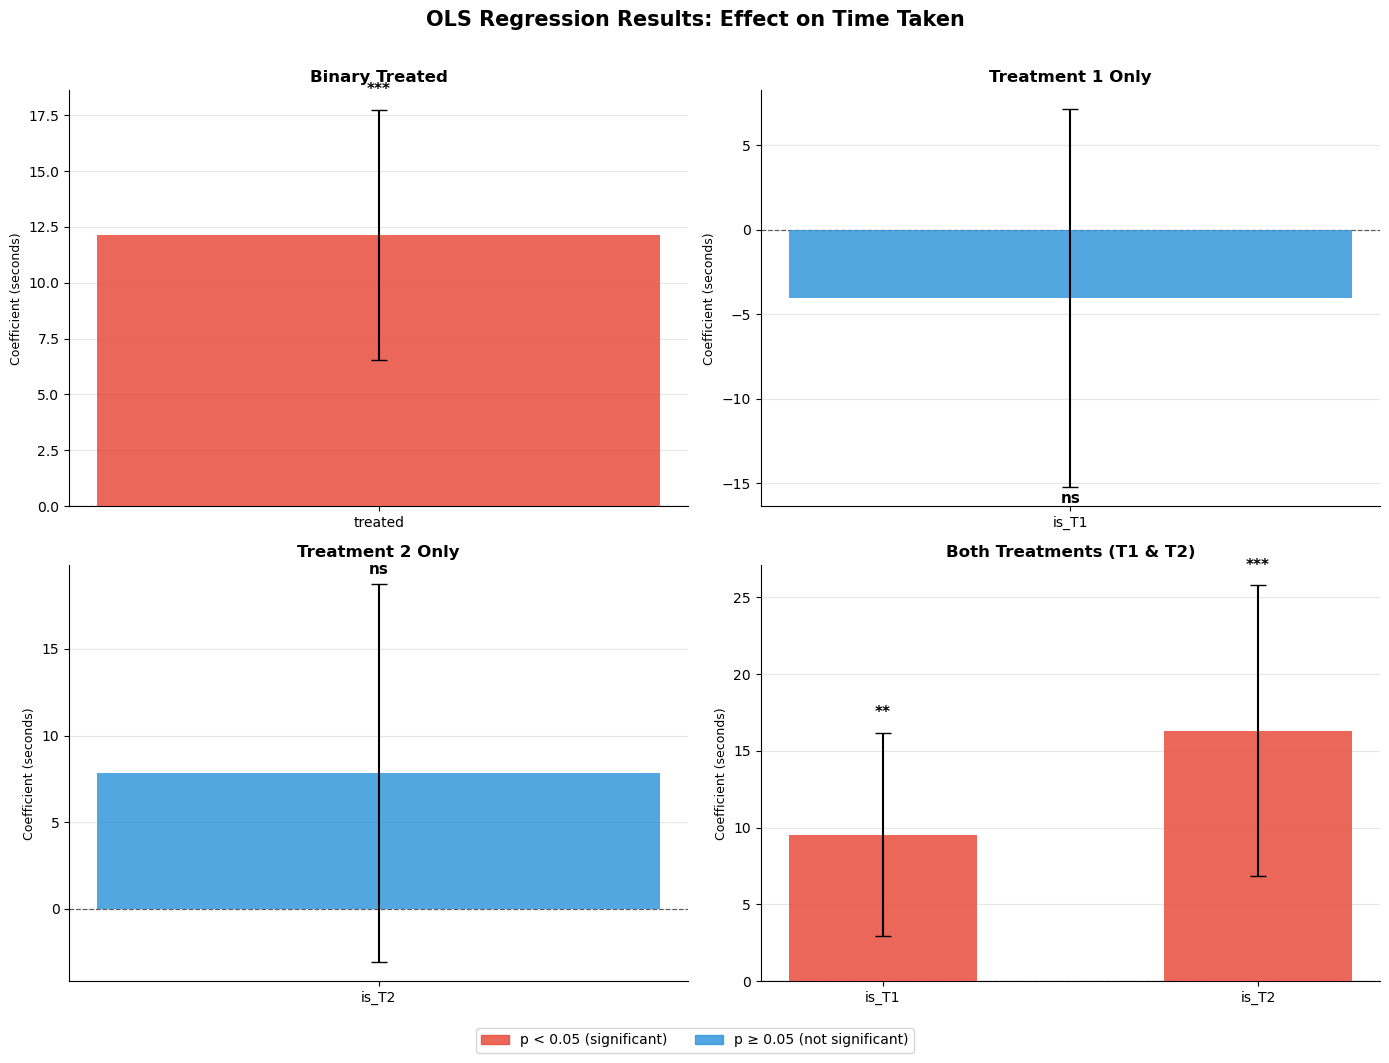

Saved → regression_plots.png


In [29]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("OLS Regression Results: Effect on Time Taken", fontsize=15, fontweight='bold', y=1.01)
axes = axes.flatten()

plot_order = ["treated_binary", "treatment1_only", "treatment2_only", "both_treatments"]
titles = {
    "treated_binary":   "Binary Treated",
    "treatment1_only":  "Treatment 1 Only",
    "treatment2_only":  "Treatment 2 Only",
    "both_treatments":  "Both Treatments (T1 & T2)",
}

for ax, name in zip(axes, plot_order):
    if name not in regs:
        ax.set_visible(False)
        continue

    fit = regs[name]

    # drop intercept for cleaner plot
    params  = fit.params.drop('Intercept', errors='ignore')
    errs    = fit.bse.drop('Intercept', errors='ignore')
    pvals   = fit.pvalues.drop('Intercept', errors='ignore')
    ci_low  = fit.conf_int().drop('Intercept', errors='ignore')[0]
    ci_high = fit.conf_int().drop('Intercept', errors='ignore')[1]

    x      = np.arange(len(params))
    colors = ['#e74c3c' if p < 0.05 else '#3498db' for p in pvals]

    bars = ax.bar(x, params.values, color=colors, alpha=0.85, width=0.5, zorder=3)

    # error bars (95% CI)
    ax.errorbar(
        x, params.values,
        yerr=[params.values - ci_low.values, ci_high.values - params.values],
        fmt='none', color='black', capsize=6, linewidth=1.5, zorder=4
    )

    # zero line
    ax.axhline(0, color='black', linewidth=0.9, linestyle='--', alpha=0.6)

    # annotate p-values above each bar
    for xi, (coef, p) in enumerate(zip(params.values, pvals.values)):
        stars = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        offset = (ci_high.values[xi] - coef) + abs(params.values).max() * 0.05
        ax.text(xi, coef + np.sign(coef) * offset, stars,
                ha='center', va='bottom' if coef >= 0 else 'top',
                fontsize=11, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(params.index, fontsize=10)
    ax.set_title(titles[name], fontsize=12, fontweight='bold')
    ax.set_ylabel("Coefficient (seconds)", fontsize=9)
    ax.grid(axis='y', alpha=0.3, zorder=0)
    ax.spines[['top', 'right']].set_visible(False)

# legend
sig_patch   = mpatches.Patch(color='#e74c3c', alpha=0.85, label='p < 0.05 (significant)')
insig_patch = mpatches.Patch(color='#3498db', alpha=0.85, label='p ≥ 0.05 (not significant)')
fig.legend(handles=[sig_patch, insig_patch], loc='lower center',
           ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
plt.savefig("regression_plots.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved → regression_plots.png")

## Regression with multiple features    



=== Regression: treated_binary ===
                            OLS Regression Results                            
Dep. Variable:        Q("Time Taken")   R-squared:                       0.353
Model:                            OLS   Adj. R-squared:                  0.065
Method:                 Least Squares   F-statistic:                     12.23
Date:                Fri, 20 Feb 2026   Prob (F-statistic):            0.00110
Time:                        16:59:36   Log-Likelihood:                -48.615
No. Observations:                  14   AIC:                             107.2
Df Residuals:                       9   BIC:                             110.4
Df Model:                           4                                         
Covariance Type:                  HC1                                         
                                                          coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------

/opt/anaconda3/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=14 observations were given.
  return hypotest_fun_in(*args, **kwds)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 5, but rank is 4
  warnings.warn('covariance of constraints does not have full '
/opt/anaconda3/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=14 observations were given.
  return hypotest_fun_in(*args, **kwds)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 5, but rank is 4
  warnings.warn('covariance of constraints does not have full '
/opt/anacond

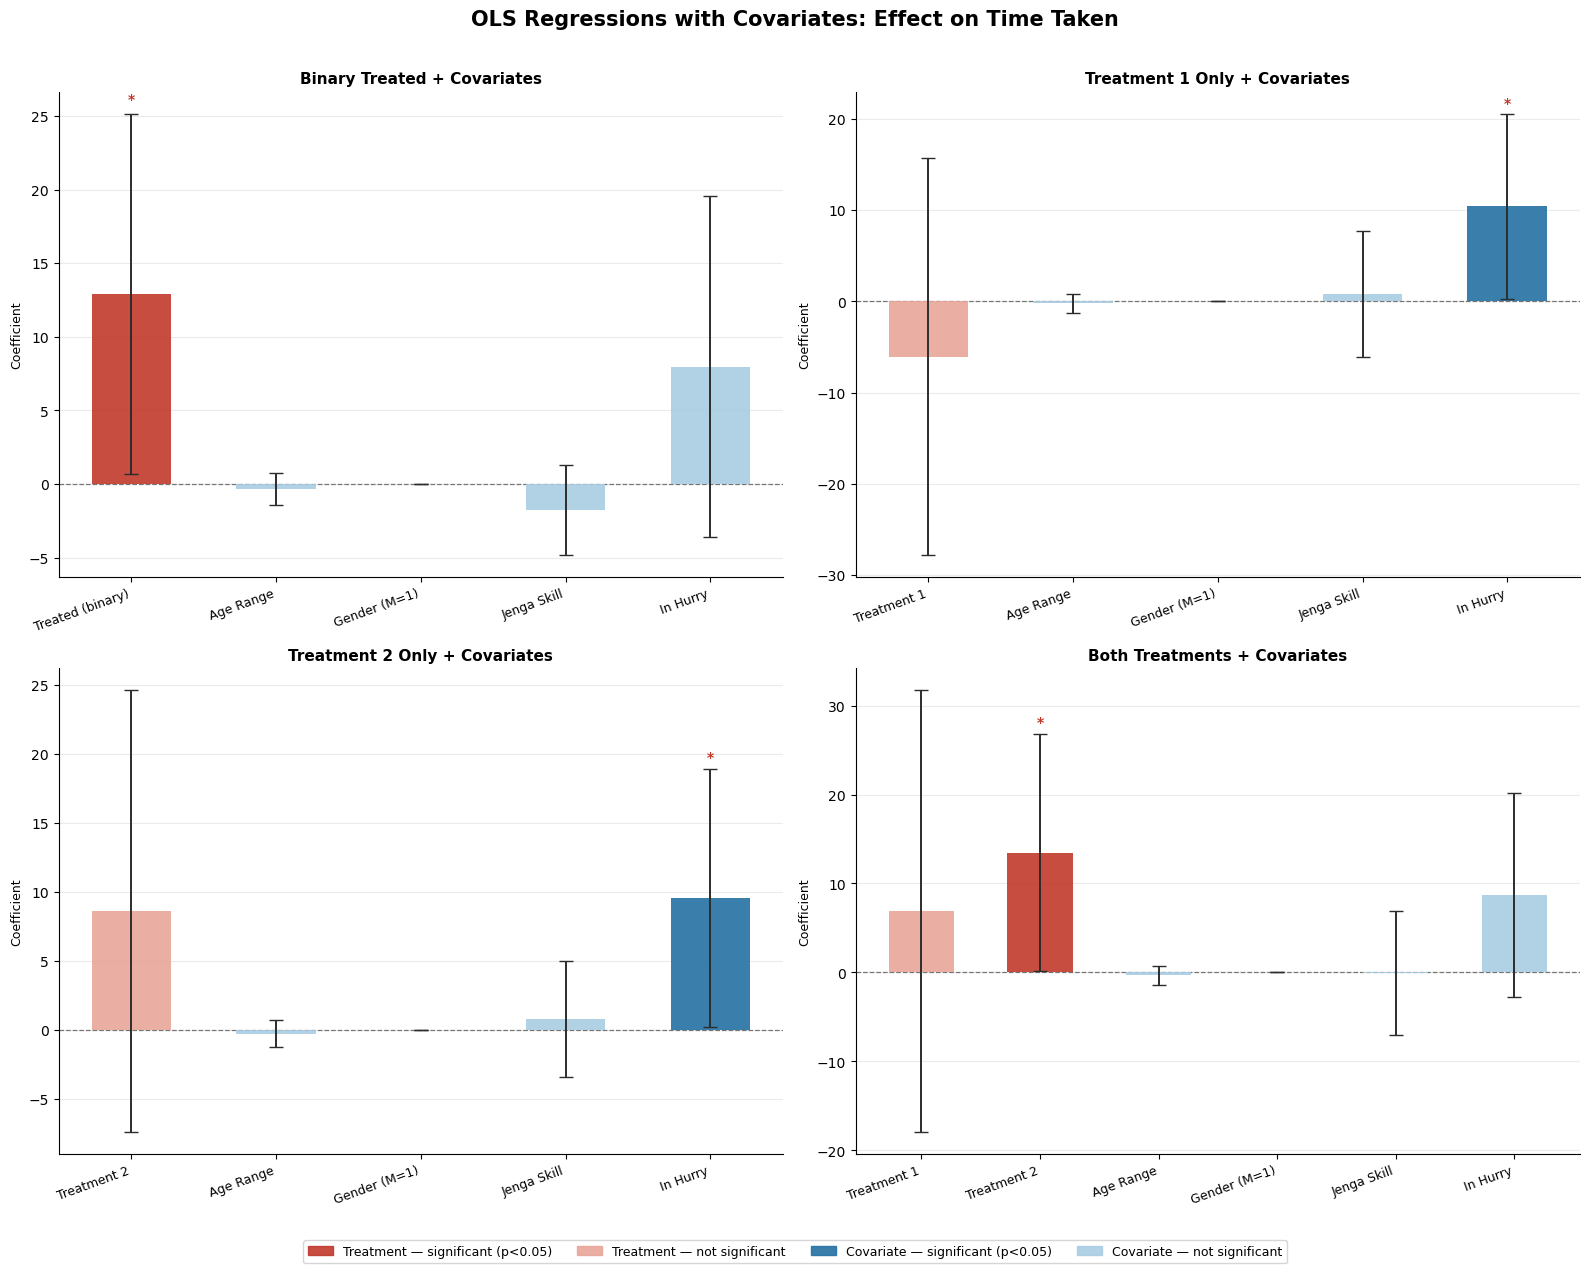

Saved → regression_covariates_plots.png


In [30]:
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

# ── 1. Prep covariates ──────────────────────────────────────────────────────
covariate_cols = [
    "What is your age range?",
    "What is your gender?",
    "How would you rate your Jenga building skills?",
    "in_hurry"
]

# Coerce numerics
for col in ["What is your age range?", "How would you rate your Jenga building skills?", "in_hurry"]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Encode gender: M=1, F=0 (drops into regression as numeric)
df['gender_M'] = (df["What is your gender?"].astype(str).str.strip().str.upper() == 'M').astype(int)

# Coerce outcome
df['Time Taken'] = pd.to_numeric(df['Time Taken'], errors='coerce')

# Ensure treatment dummies exist
if 'treatment_numeric' not in df.columns:
    raise KeyError("treatment_numeric column not found. Run mapping cell first.")
df['is_T1'] = (df['treatment_numeric'] == 1).astype(int)
df['is_T2'] = (df['treatment_numeric'] == 2).astype(int)

# Quoted covariate names for patsy formulas (spaces → Q())
cov_terms = [
    'Q("What is your age range?")',
    'gender_M',
    'Q("How would you rate your Jenga building skills?")',
    'in_hurry'
]
cov_str = " + ".join(cov_terms)

# ── 2. Define formulas ──────────────────────────────────────────────────────
formulas = {
    "treated_binary":   f'Q("Time Taken") ~ treated + {cov_str}',
    "treatment1_only":  f'Q("Time Taken") ~ is_T1 + {cov_str}',
    "treatment2_only":  f'Q("Time Taken") ~ is_T2 + {cov_str}',
    "both_treatments":  f'Q("Time Taken") ~ is_T1 + is_T2 + {cov_str}',
}

# Columns needed per regression (for dropna)
base_cols = ['Time Taken', 'gender_M', 'What is your age range?',
             'How would you rate your Jenga building skills?', 'in_hurry']

reg_extra = {
    "treated_binary":  ['treated'],
    "treatment1_only": ['is_T1'],
    "treatment2_only": ['is_T2'],
    "both_treatments": ['is_T1', 'is_T2'],
}

# ── 3. Run regressions ──────────────────────────────────────────────────────
regs = {}
for name, formula in formulas.items():
    cols = base_cols + reg_extra[name]
    df_reg = df[cols].dropna()
    if df_reg.empty:
        print(f"{name}: no data after dropping NA, skipping.")
        continue
    fit = smf.ols(formula=formula, data=df_reg).fit(cov_type='HC1')
    regs[name] = fit
    print(f"\n=== Regression: {name} ===")
    try:
        print(fit.summary())
    except Exception:
        print(fit.params.to_frame('coef')
              .join(fit.bse.to_frame('std_err'))
              .join(fit.tvalues.to_frame('t'))
              .join(fit.pvalues.to_frame('p-value'))
              .round(4))

# ── 4. Clean label mapping ──────────────────────────────────────────────────
label_map = {
    'treated':                                      'Treated (binary)',
    'is_T1':                                        'Treatment 1',
    'is_T2':                                        'Treatment 2',
    'Q("What is your age range?")':                 'Age Range',
    'gender_M':                                     'Gender (M=1)',
    'Q("How would you rate your Jenga building skills?")': 'Jenga Skill',
    'in_hurry':                                     'In Hurry',
}

titles = {
    "treated_binary":   "Binary Treated + Covariates",
    "treatment1_only":  "Treatment 1 Only + Covariates",
    "treatment2_only":  "Treatment 2 Only + Covariates",
    "both_treatments":  "Both Treatments + Covariates",
}

# ── 5. Plot ─────────────────────────────────────────────────────────────────
# Color scheme: treatment vars vs covariate vars
TREATMENT_VARS = {'treated', 'is_T1', 'is_T2'}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("OLS Regressions with Covariates: Effect on Time Taken",
             fontsize=15, fontweight='bold', y=1.01)
axes = axes.flatten()

plot_order = ["treated_binary", "treatment1_only", "treatment2_only", "both_treatments"]

for ax, name in zip(axes, plot_order):
    if name not in regs:
        ax.set_visible(False)
        continue

    fit = regs[name]

    params  = fit.params.drop('Intercept', errors='ignore')
    errs    = fit.bse.drop('Intercept', errors='ignore')
    pvals   = fit.pvalues.drop('Intercept', errors='ignore')
    ci_low  = fit.conf_int().drop('Intercept', errors='ignore')[0]
    ci_high = fit.conf_int().drop('Intercept', errors='ignore')[1]

    labels = [label_map.get(p, p) for p in params.index]
    x      = np.arange(len(params))

    # Color logic: significant treatment = red, insig treatment = salmon,
    #              significant covariate = steelblue, insig covariate = lightblue
    def bar_color(var, p):
        is_treat = var in TREATMENT_VARS
        sig = p < 0.05
        if is_treat:
            return '#c0392b' if sig else '#e8a598'
        else:
            return '#2471a3' if sig else '#a9cce3'

    colors = [bar_color(v, p) for v, p in zip(params.index, pvals.values)]

    ax.bar(x, params.values, color=colors, alpha=0.9, width=0.55, zorder=3)

    # 95% CI error bars
    ax.errorbar(
        x, params.values,
        yerr=[params.values - ci_low.values, ci_high.values - params.values],
        fmt='none', color='#2c2c2c', capsize=5, linewidth=1.4, zorder=4
    )

    # Zero reference line
    ax.axhline(0, color='black', linewidth=0.9, linestyle='--', alpha=0.5)

    # Significance stars
    for xi, (coef, p, ci_h) in enumerate(zip(params.values, pvals.values, ci_high.values)):
        stars = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        if stars:
            offset = abs(ci_h - coef) + abs(params.values).max() * 0.04
            ax.text(xi, coef + np.sign(coef) * offset, stars,
                    ha='center', va='bottom' if coef >= 0 else 'top',
                    fontsize=10, fontweight='bold', color='#c0392b')

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=9, rotation=20, ha='right')
    ax.set_title(titles[name], fontsize=11, fontweight='bold')
    ax.set_ylabel("Coefficient", fontsize=9)
    ax.grid(axis='y', alpha=0.25, zorder=0)
    ax.spines[['top', 'right']].set_visible(False)

# Legend
legend_patches = [
    mpatches.Patch(color='#c0392b', alpha=0.9, label='Treatment — significant (p<0.05)'),
    mpatches.Patch(color='#e8a598', alpha=0.9, label='Treatment — not significant'),
    mpatches.Patch(color='#2471a3', alpha=0.9, label='Covariate — significant (p<0.05)'),
    mpatches.Patch(color='#a9cce3', alpha=0.9, label='Covariate — not significant'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=4,
           fontsize=9, bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
plt.savefig("regression_covariates_plots.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved → regression_covariates_plots.png")